<a href="https://colab.research.google.com/github/gkhamis04/George-Khamis/blob/main/Calories_Burnt_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Done 🚀")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Done 🚀


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruchikakumbhar/calories-burnt-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'calories-burnt-prediction' dataset.
Path to dataset files: /kaggle/input/calories-burnt-prediction


In [ ]:
import os
import shutil

shutil.copytree(path, "./calories", dirs_exist_ok=True)
print("Done! 🚀")

Done! 🚀


**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/calories/calories.csv')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [ ]:
df.shape

(15000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,15000.0,1.497736e+07,2.872851e+06,10001159.0,12474190.75,14997285.0,17449278.75,19999647.0
Age,15000.0,4.278980e+01,1.698026e+01,20.0,28.00,39.0,56.00,79.0
Height,15000.0,1.744651e+02,1.425811e+01,123.0,164.00,175.0,185.00,222.0
Weight,15000.0,7.496687e+01,1.503566e+01,36.0,63.00,74.0,87.00,132.0
Duration,15000.0,1.553060e+01,8.319203e+00,1.0,8.00,16.0,23.00,30.0
Heart_Rate,15000.0,9.551853e+01,9.583328e+00,67.0,88.00,96.0,103.00,128.0
Body_Temp,15000.0,4.002545e+01,7.792299e-01,37.1,39.60,40.2,40.60,41.5
Calories,15000.0,8.953953e+01,6.245698e+01,1.0,35.00,79.0,138.00,314.0


**Exploratory Data Analysis**

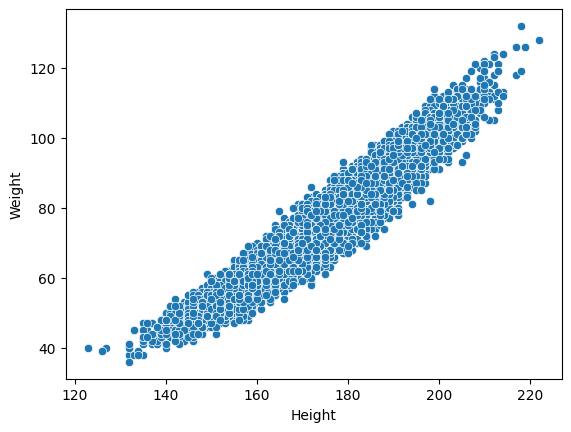

In [ ]:
sns.scatterplot(x='Height', y='Weight', data=df)
plt.show()

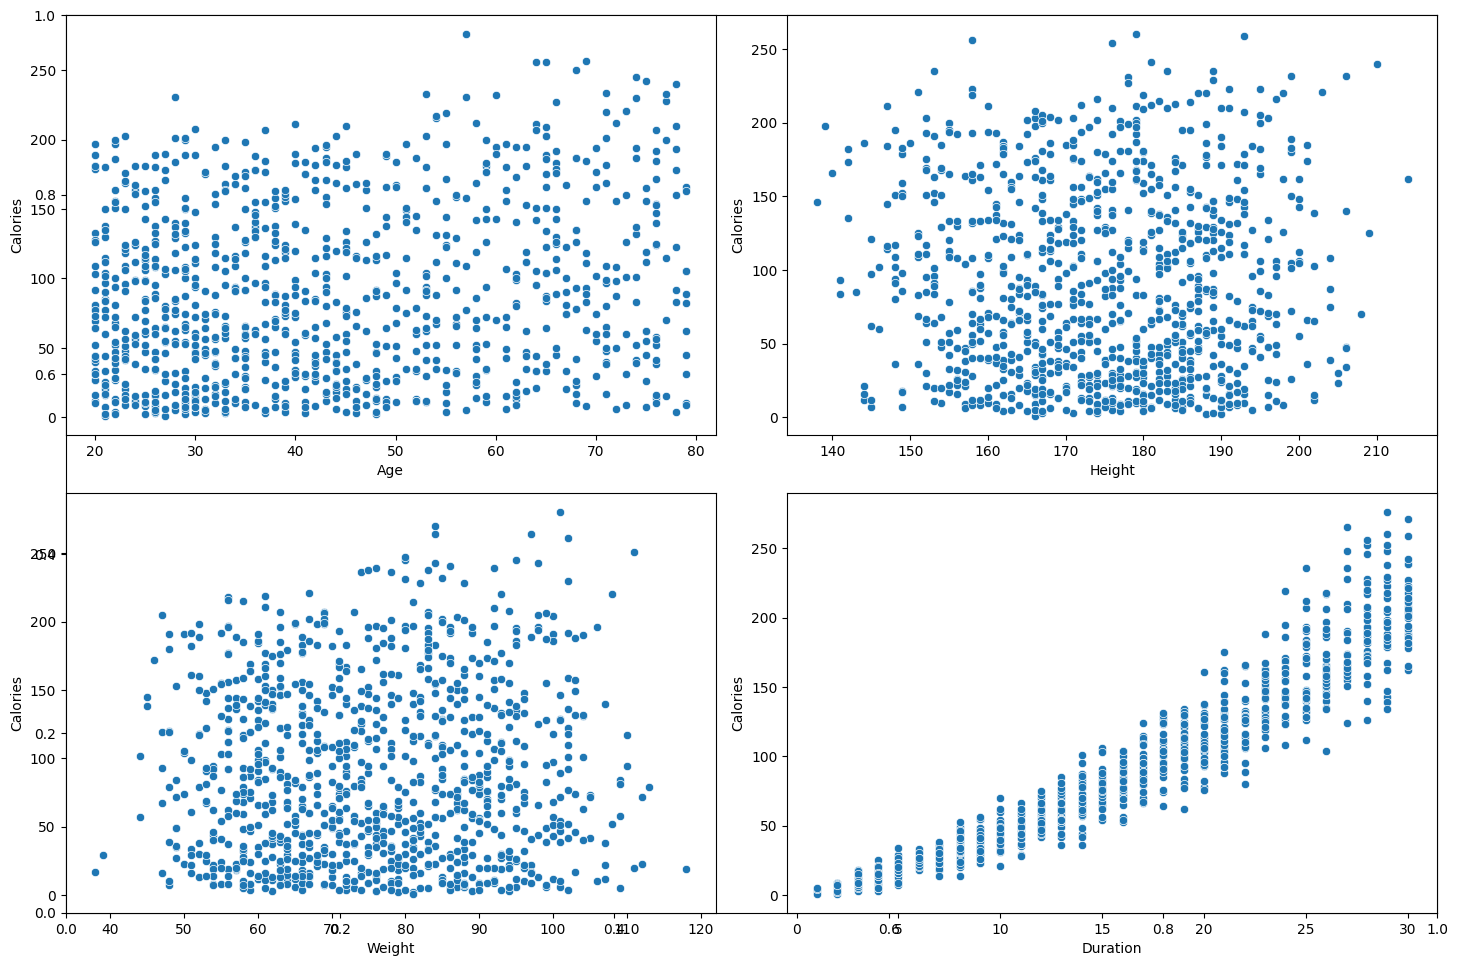

In [ ]:
features = ['Age', 'Height', 'Weight', 'Duration']
plt.subplots(figsize = (15,10))
for i, col in enumerate(features):
  plt.subplot(2, 2, i+1)
  x = df.sample(1000)
  sns.scatterplot(x=col, y="Calories", data = x)
plt.tight_layout()
plt.show()

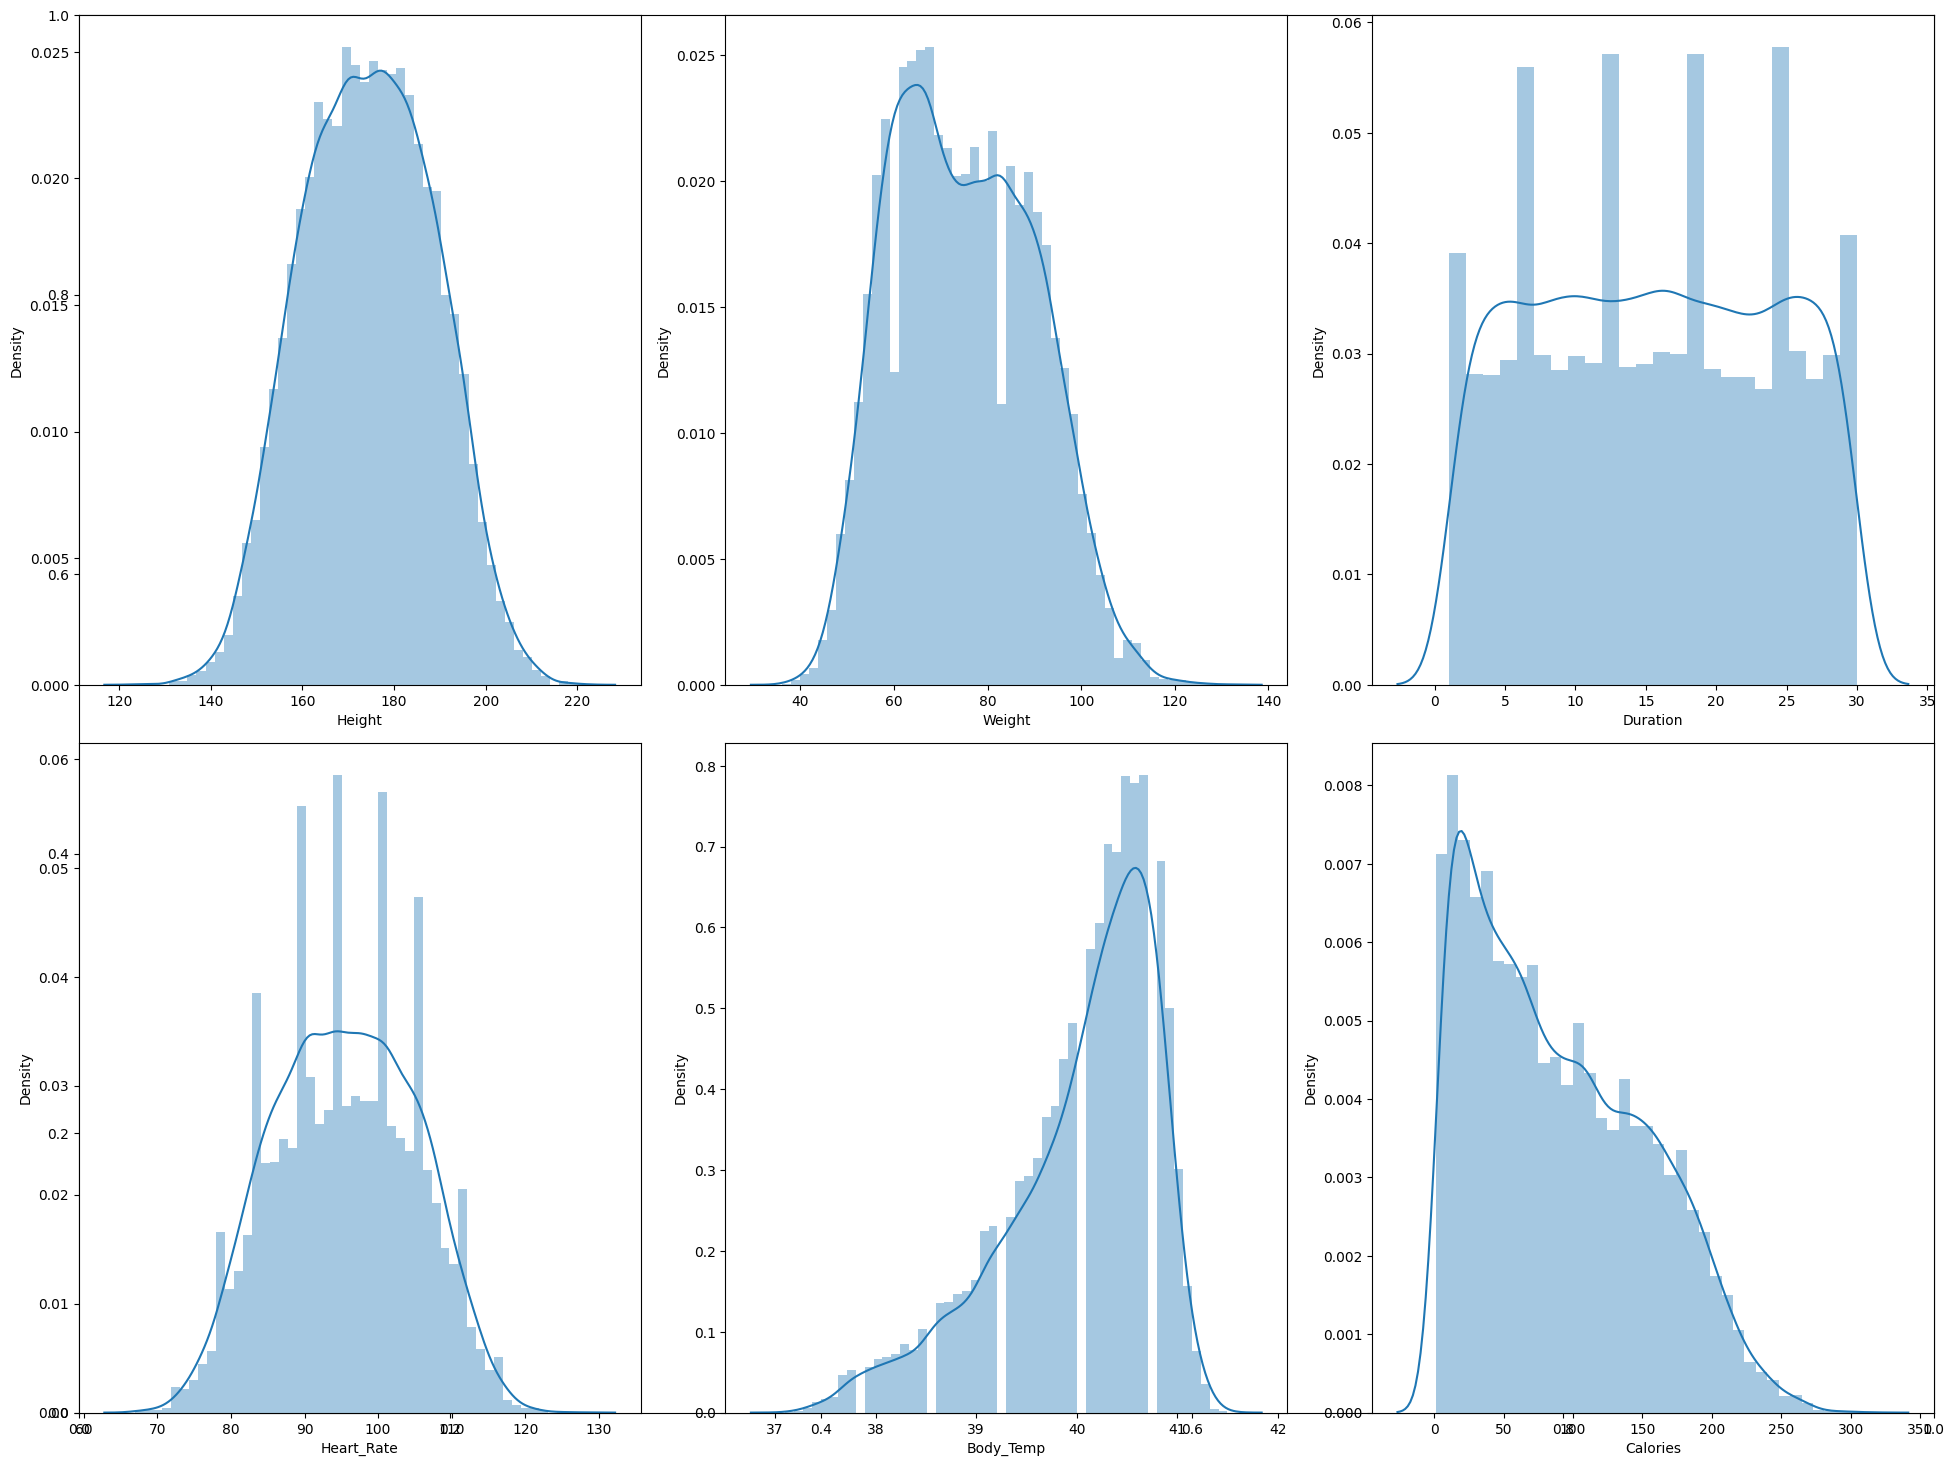

In [ ]:
features = df.select_dtypes(include = 'float').columns
plt.subplots(figsize=(20,15))
for i,col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

In [ ]:
df.replace({'male': 0, 'female': 1},
           inplace=True)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


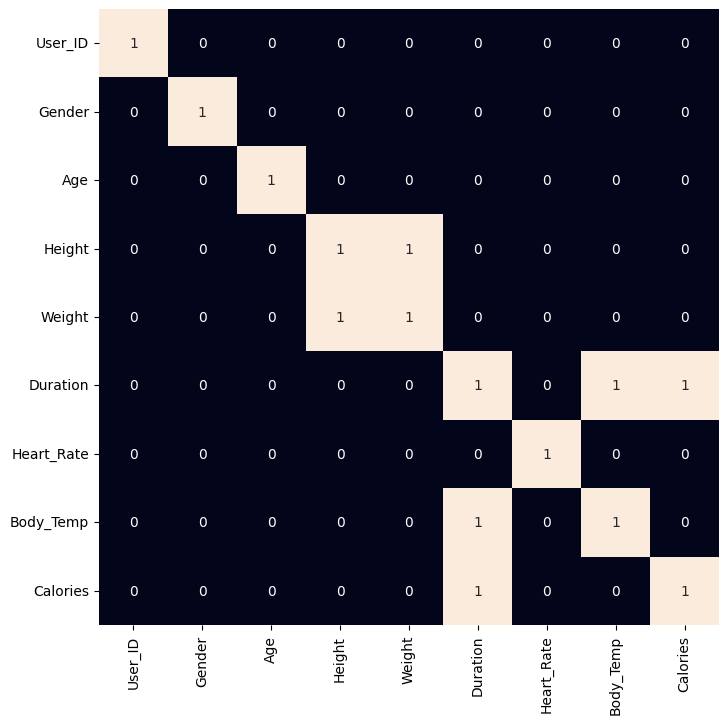

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.corr() > 0.9,
           annot=True,
           cbar=False)
plt.show()

In [ ]:
df.drop(["User_ID",'Weight', 'Body_Temp'], axis=1, inplace=True)

In [ ]:
features = df.drop(["Calories"], axis = 1)
target = df["Calories"].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=22)

In [ ]:
df.head()

,Gender,Age,Height,Duration,Heart_Rate,Calories
0,0,68,190.0,29.0,105.0,231.0
1,1,20,166.0,14.0,94.0,66.0
2,0,69,179.0,5.0,88.0,26.0
3,1,34,179.0,13.0,100.0,71.0
4,1,27,154.0,10.0,81.0,35.0


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
for model in models:
    model.fit(x_train, y_train)

    predictions = model.predict(x_test)
    train_score = model.score(x_train, y_train)
    test_score = model.score(x_test, y_test)
    mse_val = mean_squared_error(y_test, predictions)

    print(f"=== {model.__class__.__name__} ===")
    print(f"  Training Score (R²) : {train_score:.4f}")
    print(f"  Testing Score (R²)  : {test_score:.4f}")
    print(f"  MSE                 : {mse_val:.2f}")
    print("-" * 40)

=== LinearRegression ===
  Training Score (R²) : 0.9588
  Testing Score (R²)  : 0.9582
  MSE                 : 160.71
----------------------------------------
=== XGBRegressor ===
  Training Score (R²) : 0.9994
  Testing Score (R²)  : 0.9987
  MSE                 : 5.13
----------------------------------------
=== Lasso ===
  Training Score (R²) : 0.9580
  Testing Score (R²)  : 0.9574
  MSE                 : 163.59
----------------------------------------
=== RandomForestRegressor ===
  Training Score (R²) : 0.9997
  Testing Score (R²)  : 0.9979
  MSE                 : 7.92
----------------------------------------
=== Ridge ===
  Training Score (R²) : 0.9588
  Testing Score (R²)  : 0.9582
  MSE                 : 160.71
----------------------------------------
